# Exporting a ML model

The `engine_data.csv` dataset was obtained from [Kaggle](https://www.kaggle.com/datasets/parvmodi/automotive-vehicles-engine-health-dataset) and contains various features and measurements related to vehicle engine health. These features include engine RPM, lubrication oil pressure, fuel pressure, coolant pressure, lubrication oil temperature, and coolant temperature, among other sensor-based metrics.

The dataset is designed for predictive maintenance tasks and is used to determine whether an engine requires maintenance or not. The target variable indicates the engine condition as a binary outcome (maintenance required = 1, no maintenance required = 0).

In [2]:
import kagglehub

path = kagglehub.dataset_download("parvmodi/automotive-vehicles-engine-health-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\renat\.cache\kagglehub\datasets\parvmodi\automotive-vehicles-engine-health-dataset\versions\1


In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PowerTransformer, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

In [4]:
path = Path(path) / Path("engine_data.csv")
data = pd.read_csv(path)
data.head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
0,700,2.493592,11.790927,3.178981,84.144163,81.632187,1
1,876,2.941606,16.193866,2.464504,77.640934,82.445724,0
2,520,2.961746,6.553147,1.064347,77.752266,79.645777,1
3,473,3.707835,19.510172,3.727455,74.129907,71.774629,1
4,619,5.672919,15.738871,2.052251,78.396989,87.000225,0


## EDA 

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 19535 entries, 0 to 19534
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Engine rpm        19535 non-null  int64  
 1   Lub oil pressure  19535 non-null  float64
 2   Fuel pressure     19535 non-null  float64
 3   Coolant pressure  19535 non-null  float64
 4   lub oil temp      19535 non-null  float64
 5   Coolant temp      19535 non-null  float64
 6   Engine Condition  19535 non-null  int64  
dtypes: float64(5), int64(2)
memory usage: 1.0 MB


In [6]:
missing_percent = data.isnull().mean() * 100
missing_percent.sort_values(ascending=False)

Engine rpm          0.0
Lub oil pressure    0.0
Fuel pressure       0.0
Coolant pressure    0.0
lub oil temp        0.0
Coolant temp        0.0
Engine Condition    0.0
dtype: float64

The dataset consists of 19,535 records and 7 columns, each representing sensor measurements and the engine condition of vehicles. The features are:

- **Engine rpm**: Engine revolutions per minute (integer)
- **Lub oil pressure**: Lubrication oil pressure (float)
- **Fuel pressure**: Fuel system pressure (float)
- **Coolant pressure**: Coolant system pressure (float)
- **Lub oil temp**: Lubrication oil temperature (float)
- **Coolant temp**: Coolant temperature (float)
- **Engine Condition**: Target variable indicating engine health (1 = maintenance required, 0 = no maintenance required, integer)

All columns are complete with no missing values.

In [7]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Engine rpm,19535.0,791.239263,267.611193,61.000000,593.000000,746.000000,934.000000,2239.000000
Lub oil pressure,19535.0,3.303775,1.021643,0.003384,2.518815,3.162035,4.055272,7.265566
Fuel pressure,19535.0,6.655615,2.761021,0.003187,4.916886,6.201720,7.744973,21.138326
Coolant pressure,19535.0,2.335369,1.036382,0.002483,1.600466,2.166883,2.848840,7.478505
lub oil temp,19535.0,77.643420,3.110984,71.321974,75.725990,76.817350,78.071691,89.580796
Coolant temp,19535.0,78.427433,6.206749,61.673325,73.895421,78.346662,82.915411,195.527912
Engine Condition,19535.0,0.630509,0.482679,0.000000,0.000000,1.000000,1.000000,1.000000


### Numerical Features

The numerical features are the following:

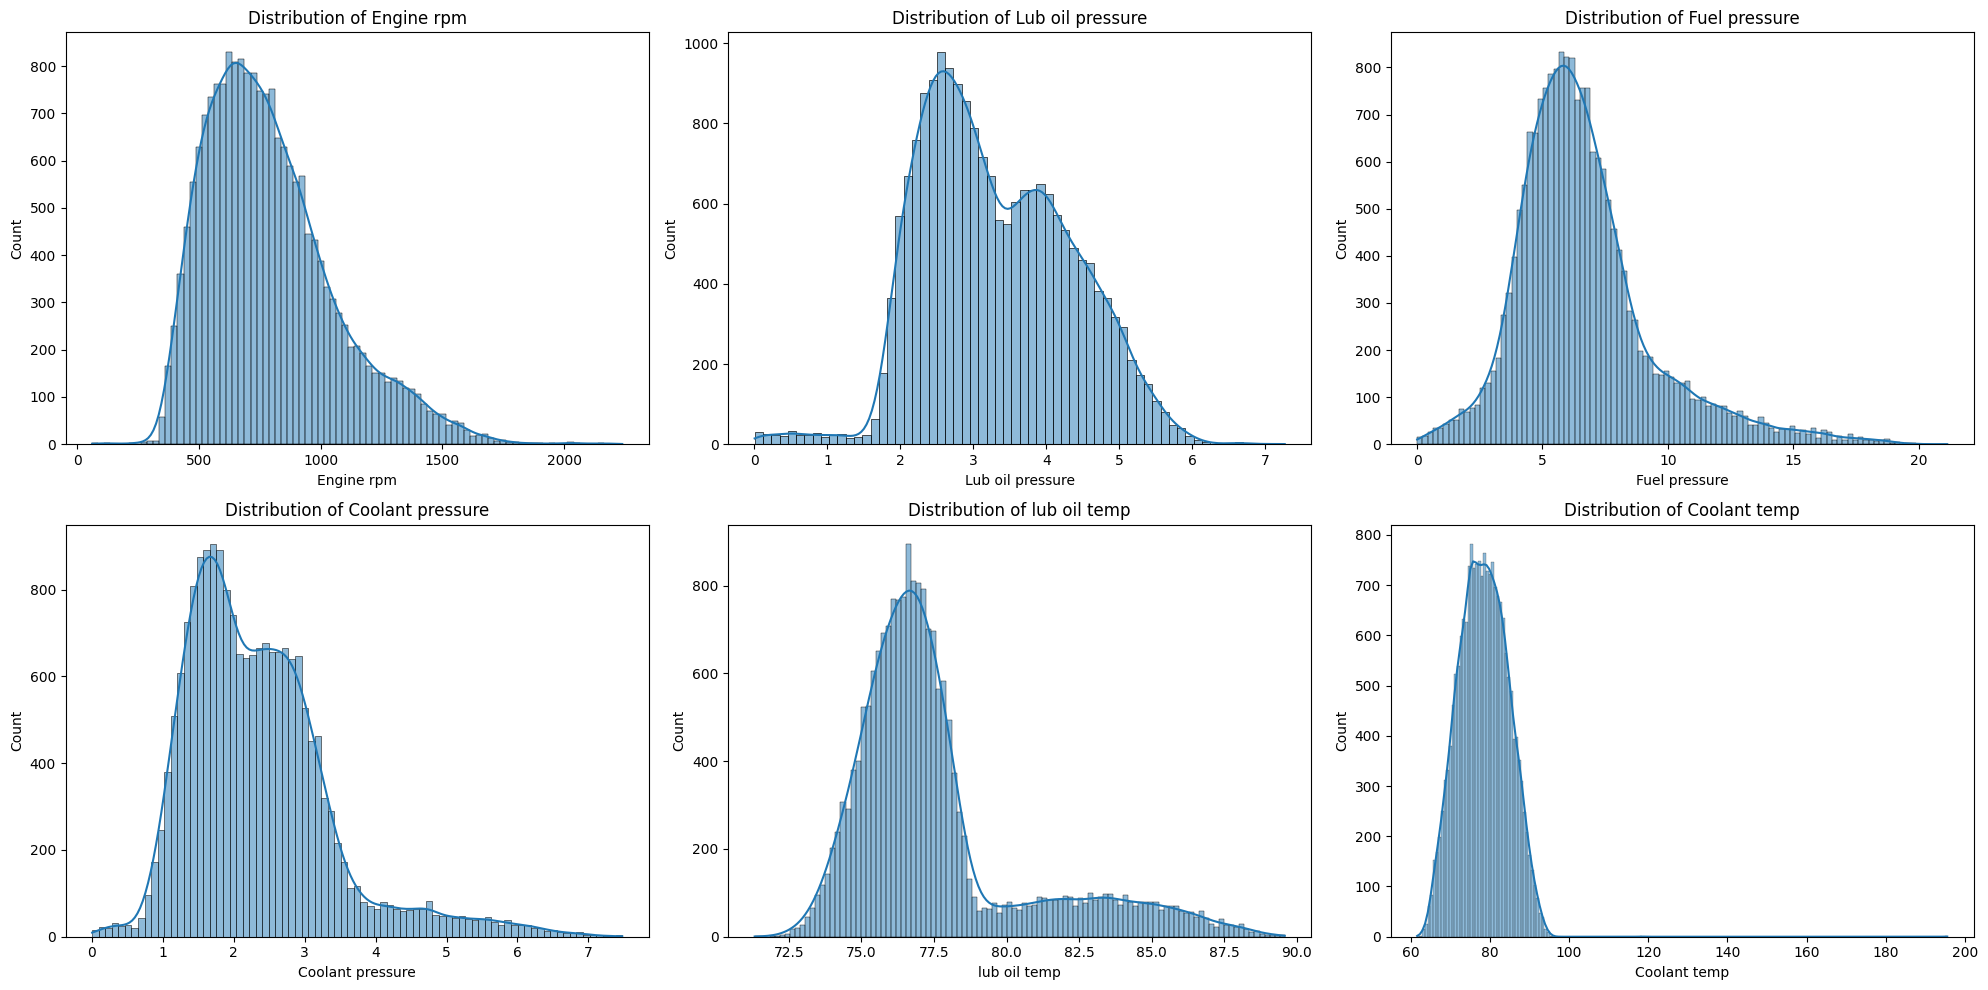

In [8]:
numerical_cols = [
    'Engine rpm', 'Lub oil pressure', 'Fuel pressure', 'Coolant pressure', 'lub oil temp', 'Coolant temp'
]

fig, axs = plt.subplots(2, 3, figsize=(20, 10))

for ax, col in zip(axs.ravel(), numerical_cols):
    sns.histplot(data[col], ax=ax, kde=True)
    ax.set_title(f'Distribution of {col}')

fig.tight_layout()

### Target variable analysis

The target variable `Engine Condition` indicates the health status of the vehicle's engine. It is binary, where:
- `1` means maintenance is required.
- `0` means no maintenance is required.


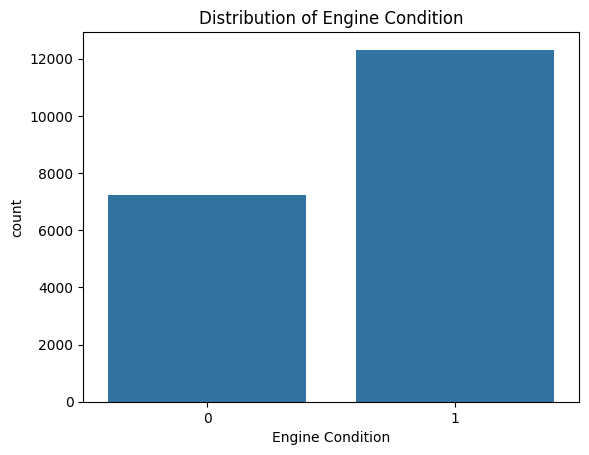

In [9]:
ax = sns.countplot(x="Engine Condition", data=data)
ax.set_title("Distribution of Engine Condition")
plt.show()

According to the distribution plot, the value `1` is the majority. This means that there are many engines in the dataset that were detected as requiring maintenance. This demonstrates an imbalanced distribution of the target variable.

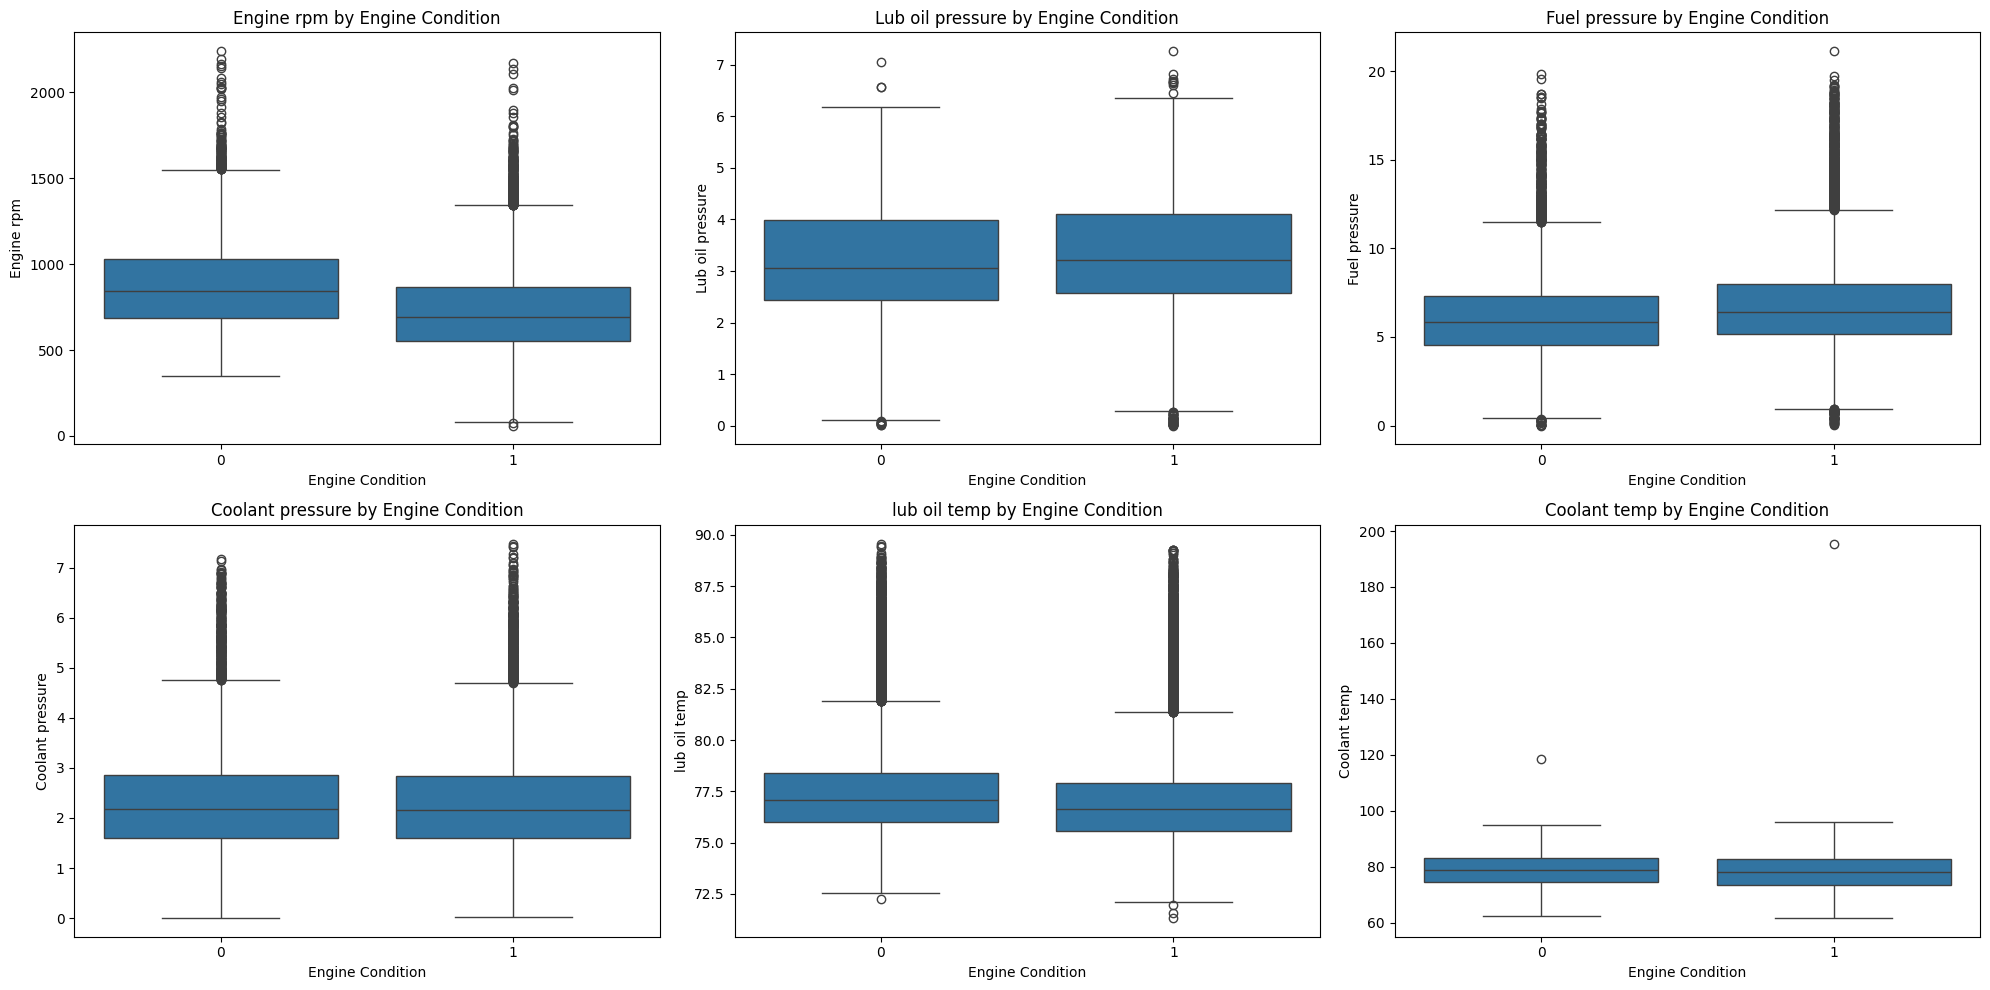

In [10]:
fig, axs = plt.subplots(2, 3, figsize=(20, 10))

for ax, col in zip(axs.ravel(), numerical_cols):
    sns.boxplot(x='Engine Condition', y=col, data=data, ax=ax)
    ax.set_title(f'{col} by Engine Condition')

fig.tight_layout()

The previous graphs suggest some key findings:

- All numerical features show very similar distributions between engines that require maintenance and those that do not.
- The values of the features overlap significantly between both classes, indicating that no single variable clearly distinguishes the engine condition.
- Outliers are present in all features, but they are not associated with any specific class.
- The boxplots suggest that engine condition likely depends on the combination of several features, rather than just one.

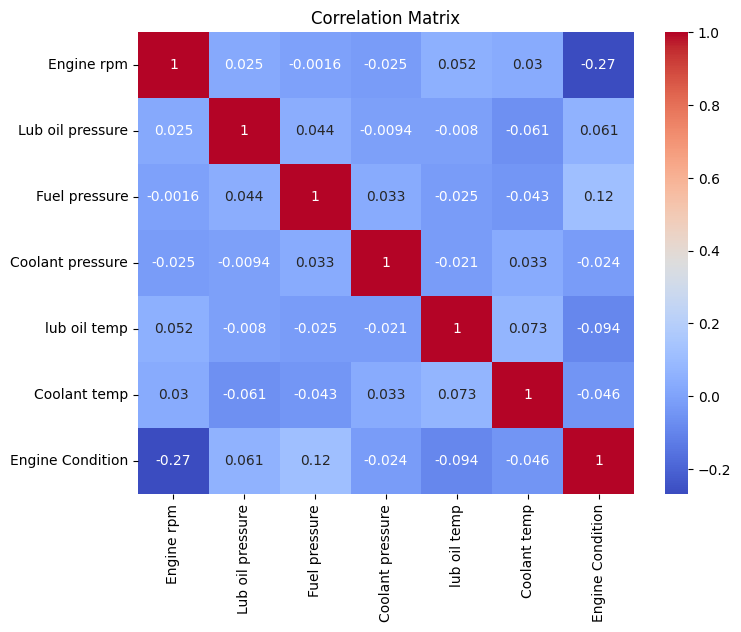

In [11]:
corr = data.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

The key findings for the correlation matrix are the following:

- None of the features has a strong correlation with the target variable `Engine Condition`. All values are close to 0, which means there is no clear linear relationship.
- The correlations between features are also low, indicating that the features are independent from each other.
- The feature `Engine rpm` has a moderate negative correlation (-0.27) with engine condition, suggesting that engines with higher rpm are less likely to require maintenance.

The previous analysis suggest that all columns play an important role in determining whether an engine requires maintenance. Since none of the features alone can clearly distinguish the engine condition, and their distributions overlap significantly between classes, it is likely that the prediction depends on the combination of several features. Therefore, we cannot remove any columns at this stage, as each one contributes valuable information to the model. Further feature selection techniques could be applied later, but initially, all variables should be included to ensure the model captures all relevant patterns.

Therefore, we will use the following features:
* `Engine rpm`
* `Lub oil pressure`
* `Fuel pressure`
* `Coolant pressure`
* `lub oil temp`
* `Coolant temp`

## Preprocessing Pipeline

The following preprocessing pipeline was chosen based on the previous analysis of the data distributions and feature characteristics:

* `PowerTransformer`: This transformation is applied to the features `Lub oil pressure`, `Coolant pressure`, and `lub oil temp` because their distributions are noticeably skewed or non-normal, as observed in the histograms. PowerTransformer helps to make these distributions more Gaussian-like, which can improve the performance of the model.

* `StandardScaler`: This scaler is applied to all numerical features to ensure that each variable has a mean of 0 and a standard deviation of 1. This standardization is important because it puts all features on the same scale, preventing variables with larger ranges from dominating the model and ensuring that all features contribute equally to the learning process.

In [12]:
preprocessing_pipeline = ColumnTransformer(
    transformers=[
        ('power', PowerTransformer(), ['Lub oil pressure', 'Coolant pressure', 'lub oil temp']),
        ('scaler', StandardScaler(), numerical_cols)
    ]
)

Split the dataset into features `X` and target `y`, then create training and test sets.

In [13]:
X = data.drop(columns=['Engine Condition'])
y = data['Engine Condition']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

The `stratify` parameter was used to preserve the original distribution of the target variable `Engine Condition` in both sets, ensuring that the proportion of each class remains consistent for model evaluation.

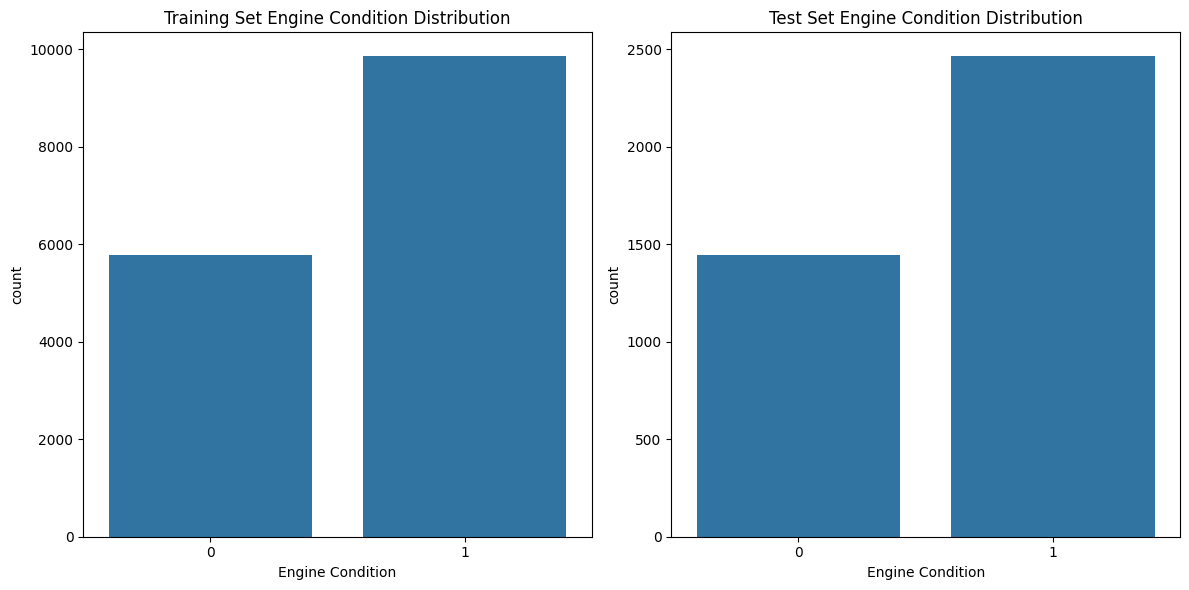

In [14]:
fig, axs = plt.subplots(1 , 2, figsize=(12, 6))
sns.countplot(x=y_train, ax=axs[0])
axs[0].set_title('Training Set Engine Condition Distribution')
sns.countplot(x=y_test, ax=axs[1])
axs[1].set_title('Test Set Engine Condition Distribution')
plt.tight_layout()

In [15]:
x_train_processed = preprocessing_pipeline.fit_transform(x_train)
x_test_processed = preprocessing_pipeline.transform(x_test)

## Training and evaluating the model

`Recall` was chosen as the main evaluation metric because the dataset is imbalanced and the primary objective is to minimize false negatives, ensuring that engines requiring maintenance are correctly identified. This is critical in predictive maintenance scenarios, where missing a faulty engine can have significant consequences.

`Logistic Regression` was selected for training due to its simplicity and strong performance in this problem, achieving a high recall score, which is essential for identifying engines that require maintenance in imbalanced datasets.

In [16]:
logistic_regression_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

logistic_regression_grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=1000),
    param_grid=logistic_regression_param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring='recall'
)

logistic_regression_grid_search.fit(x_train_processed, y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


c:\Users\renat\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'penalty': ['l2'], 'solver': ['lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also display

In [17]:
logistic_regression_best_model = logistic_regression_grid_search.best_estimator_

def evaluate_model(model, X, y):
    from sklearn.metrics import recall_score
    y_pred = model.predict(X)
    return {
        'Recall': recall_score(y, y_pred)
    }

logistic_regression_test_metrics = evaluate_model(logistic_regression_best_model, x_test_processed, y_test)

logistic_regression_metrics_df = pd.DataFrame([logistic_regression_test_metrics])

logistic_regression_metrics_df['CV Recall Score'] = logistic_regression_grid_search.best_score_

logistic_regression_metrics_df['Overfitting'] = logistic_regression_metrics_df['CV Recall Score'] - logistic_regression_metrics_df['Recall']

logistic_regression_metrics_df.index = ['Logistic Regression']

logistic_regression_metrics_df

,Recall,CV Recall Score,Overfitting
Logistic Regression,0.880633,0.880557,-0.000076


`Logistic Regression` achieved a high recall (0.88), minimizing false negatives. Additionally, the model shows almost no overfitting, as recall scores are consistent between cross-validation and test data.

## Exporting the model

Convert the Engine Condition model to ONNX

In [26]:
from sklearn.pipeline import Pipeline
from skl2onnx import to_onnx
import numpy as np

pipe = Pipeline([
    ('preprocessing', preprocessing_pipeline),
    ('classifier', logistic_regression_best_model)
])

onx = to_onnx(pipe, X[:1].astype(np.float32), options={'zipmap': False})

with open("engine_condition.onnx", "wb") as f:
    f.write(onx.SerializeToString())

In [33]:
import onnxruntime as ort

session = ort.InferenceSession("engine_condition.onnx")

input_dict = {
    'Engine_rpm': np.array([[2500]], dtype=np.float32),
    'Lub_oil_pressure': np.array([[3.2]], dtype=np.float32),
    'Fuel_pressure': np.array([[2.8]], dtype=np.float32),
    'Coolant_pressure': np.array([[1.5]], dtype=np.float32),
    'lub_oil_temp': np.array([[85.0]], dtype=np.float32),
    'Coolant_temp': np.array([[90.0]], dtype=np.float32)
}

pred = session.run(None, input_dict)
print(pred)

[array([0]), array([[0.9784906 , 0.02150941]], dtype=float32)]


In [34]:
session = ort.InferenceSession("engine_condition.onnx")

input_dict = {
    'Engine_rpm': np.array([[600]], dtype=np.float32),
    'Lub_oil_pressure': np.array([[3.2]], dtype=np.float32),
    'Fuel_pressure': np.array([[12]], dtype=np.float32),
    'Coolant_pressure': np.array([[2.5]], dtype=np.float32),
    'lub_oil_temp': np.array([[90]], dtype=np.float32),
    'Coolant_temp': np.array([[90]], dtype=np.float32)
}

pred = session.run(None, input_dict)
print(pred)

[array([1]), array([[0.31909853, 0.68090147]], dtype=float32)]
